In [10]:
import pandas as pd
from nltk.corpus import stopwords

In [11]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Personal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
dataset = pd.read_csv("product_reviews_mock_data.csv")
dataset.drop(columns=["ReviewID", "ProductID", "UserID", "ReviewDate"],inplace=True)

In [13]:
def encode(rating):
    if rating<=2:
       return 'Negative'
    elif rating == 3:
       return 'Neutral'
    else:
        return 'Positive'

dataset["sentiment"] = dataset["Rating"].apply(encode)

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}

In [14]:
import nltk
print(nltk.__file__)
print(nltk.__version__)

C:\Users\Personal\PycharmProjects\review-sentiment-classifier\.venv\Lib\site-packages\nltk\__init__.py
3.10.0


In [15]:
label_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

dataset["label"] = dataset["sentiment"].map(label_map)
dataset["ReviewText"] = dataset["ReviewText"].str.lower()
dataset["ReviewText"] = dataset["ReviewText"].str.replace(r"[^\w\s]", "", regex=True)




In [16]:
dataset["ReviewText"] = dataset["ReviewText"].apply(lambda x: " ".join([word for word in x.split() if word not in (set(stopwords.words("english")) - {"not", "no", "very"})]))

dataset = dataset.drop_duplicates(subset=["ReviewText"]).reset_index(drop=True)

In [17]:
nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
dataset["ReviewText"] = dataset["ReviewText"].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Personal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [18]:
dataset["sentiment"].value_counts()

sentiment
Negative    255
Positive    250
Neutral     136
Name: count, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split

X = dataset["ReviewText"]
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [21]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_train_tfidf, y_train)

svm = LinearSVC(class_weight="balanced")
svm.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm
}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))


===== Naive Bayes =====
Accuracy: 0.8062015503875969
              precision    recall  f1-score   support

    Negative       0.82      1.00      0.90        51
     Neutral       1.00      0.11      0.19        28
    Positive       0.78      1.00      0.88        50

    accuracy                           0.81       129
   macro avg       0.87      0.70      0.66       129
weighted avg       0.85      0.81      0.74       129


===== Logistic Regression =====
Accuracy: 0.9922480620155039
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        51
     Neutral       0.97      1.00      0.98        28
    Positive       1.00      0.98      0.99        50

    accuracy                           0.99       129
   macro avg       0.99      0.99      0.99       129
weighted avg       0.99      0.99      0.99       129


===== SVM =====
Accuracy: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00   

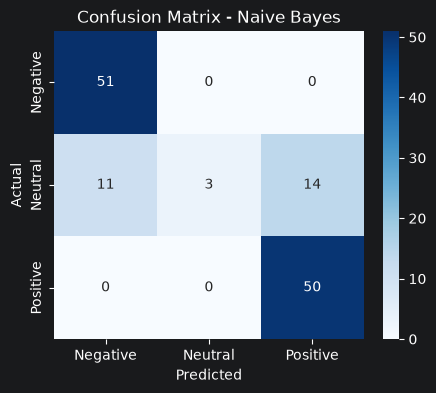

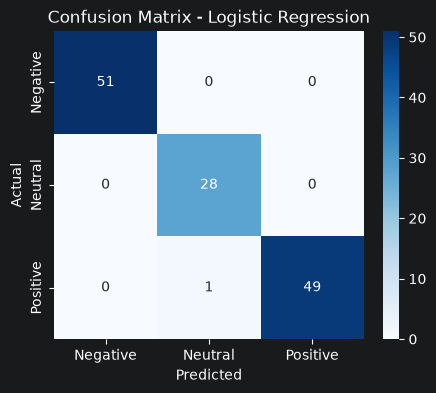

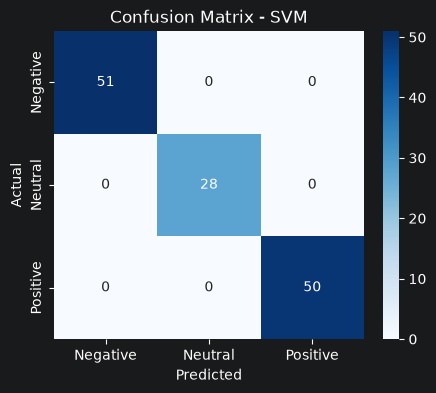

In [23]:
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Neutral", "Positive"],
                yticklabels=["Negative", "Neutral", "Positive"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"confusion_matrix_{name.replace(' ', '_')}.png")
    plt.show()

In [24]:
dataset.head(-10)

,Rating,ReviewText,sentiment,label
0,4,fantastic wonderful experience,Positive,2
1,2,broke easily awful,Negative,0
2,3,met expectation five star,Neutral,1
3,5,very satisfied wonderful experience,Positive,2
4,1,worst purchase one star,Negative,0
...,...,...,...,...
626,5,highly recommend excellent quality could better,Positive,2
627,4,five star great value average product,Positive,2
628,2,difficult use very disappointed nothing special,Negative,0
629,1,customer service bad would not recommend,Negative,0


In [25]:
import joblib

joblib.dump(lr, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [26]:
loaded_model = joblib.load("sentiment_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")


def predict_sentiment(text):
    text = text.lower()
    text_tfidf = loaded_vectorizer.transform([text])
    pred = loaded_model.predict(text_tfidf)[0]
    reverse_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
    return reverse_map[pred]


# test on sentences NOT in your dataset
print(predict_sentiment("the product stopped working after two days"))
print(predict_sentiment("it was okay, nothing special"))
print(predict_sentiment("absolutely love this, best purchase ever"))

Neutral
Neutral
Positive
